# Auto-Encoder for Colorization

![Gray scale to color](notebook_images/colorization.png)

This notebook demonstrates how to use an autoencoder to perform the task of image colorization. The input will be a greyscale image, and the output should provide enough information to reconstruct a color RGB image.

Note, however, that colorization is inherently a predictive task rather than a reconstruction. Since a single grayscale image can correspond to many possible color images, the model is trained to predict plausible colors by leveraging contextual and semantic cues learned from large datasets. Hence, the output is a best guess, not necessarily a faithful recovery of the original colors.

In [38]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

import torchinfo

import matplotlib.pyplot as plt
import numpy as np
import time

import os
import pathlib
from PIL import Image
import skimage
from tqdm import tqdm


# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, './util')
import vcpi_util

print(torch.__version__)

2.2.1+cu118


## Auxiliary functions

In [72]:
def train(model, train_loader, val_loader, epochs, loss_fn, optimizer, scheduler, early_stopper, save_prefix='model', device='cuda'):
    history = {'loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        start_time = time.time()
        running_loss = 0.0
        total_train_samples = 0
        
        for i, (inputs, targets,classes,_) in tqdm(enumerate(train_loader), desc=f"Epoch {epoch+1}/{epochs}"):
                 
            inputs = inputs.to(device)
            targets = targets.to(device)
            batch_size = inputs.size(0)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            loss.backward()
            optimizer.step()
            
            # FIX: Correct loss accumulation
            running_loss += loss.item() * batch_size
            total_train_samples += batch_size
            
        epoch_loss = running_loss / total_train_samples
        
        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        total_val_samples = 0
        
        with torch.no_grad():
            for inputs, targets,classes,_ in val_loader:
                    
                inputs = inputs.to(device)
                targets = targets.to(device)
                batch_size = inputs.size(0)
                
                outputs = model(inputs)
                batch_loss = loss_fn(outputs, targets)
                
                val_loss += batch_loss.item() * batch_size
                total_val_samples += batch_size
                
        epoch_val_loss = val_loss / total_val_samples
        
        # --- Scheduling and Logging ---
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(epoch_val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        
        if old_lr != new_lr:
            print(f'==> Learning rate updated: {old_lr:.6f} -> {new_lr:.6f}')
            
        stop_time = time.time()
        print(f'Epoch: {epoch:03d} | Loss: {epoch_loss:.6f} | Val Loss: {epoch_val_loss:.6f} | Time: {(stop_time - start_time):.4f}s')
        
        history['loss'].append(epoch_loss)
        history['val_loss'].append(epoch_val_loss)
        
        # --- Saving Best Model ---
        if epoch_val_loss < best_val_loss:
            torch.save({
                'epoch': epoch,
                'model': model.state_dict(),
                'history': history,
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict()
            }, f'{save_prefix}_best.pt')
            best_val_loss = epoch_val_loss
            
        # --- Early Stopping ---
        if early_stopper(epoch_val_loss):
            print('Early stopping triggered!')
            break
            
    print('Finished Training')
    return history

class Early_Stopping():

    def __init__(self, patience = 3, min_delta = 0.00001):

        self.patience = patience 
        self.min_delta = min_delta

        self.min_val_loss = float('inf')
        self.counter = 0

    def __call__(self, val_loss):

        # improvement
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0

        # no improvement            
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
            
        return False
     
from matplotlib import colors

def plot_scatter(x,y,targets, lims = None):
    cmap = colors.ListedColormap(['black', 'darkred', 'darkblue', 
                                  'darkgreen', 'yellow', 'brown', 
                                  'purple', 'lightgreen', 'red', 'lightblue'])
    bounds=[0, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5,8.5,9.5]
    norm = colors.BoundaryNorm(bounds, cmap.N)

    if lims != None:
        s = 50
    else: s = 1

    plt.figure(figsize=(10,10))
    plt.scatter(x, y, c = targets, cmap=cmap, s = s, norm=norm)
    plt.colorbar()
    if lims != None:
         plt.xlim(lims[0], lims[2])
         plt.ylim(lims[1], lims[3])

    plt.show()


def show_preds(set1, set2, set3, classes, count):
  
    columns = 5
    rows = count + 1  
    plt.figure(figsize=(count, .5 * rows * columns))
  
    for n in range(count):
        ax = plt.subplot(rows, columns, n*columns+1)
        plt.title(classes[n])
        plt.imshow(np.transpose(set1[n].numpy(), (1,2,0)), cmap=plt.cm.gray, vmin=-1, vmax=1)
        plt.axis('off')
        ax = plt.subplot(rows, columns, n*columns+2)
        plt.title("A")
        plt.imshow(np.transpose(set2[n].numpy(), (1,2,0))[:,:,0], cmap=plt.cm.gray, vmin=-1, vmax=1)
        plt.axis('off')
        ax = plt.subplot(rows, columns, n*columns+3)
        plt.title("B")
        plt.imshow(np.transpose(set2[n].numpy(), (1,2,0))[:,:,1], cmap=plt.cm.gray, vmin=-1, vmax=1)
        plt.axis('off')
        ax = plt.subplot(rows, columns, n*columns+4)
        plt.title("RGB")
        l_img = np.transpose(set1[n].numpy(), (1, 2, 0))
        ab_img = np.transpose(set2[n].numpy(), (1, 2, 0))

        L = np.clip(l_img[:, :, 0] * 50 + 50, 0, 100)
        a = np.clip(ab_img[:, :, 0] * 127, -128, 127)
        b = np.clip(ab_img[:, :, 1] * 127, -128, 127)

        lab = np.stack([L, a, b], axis=2)
        rgb = skimage.color.lab2rgb(lab)
        plt.imshow(rgb)
        plt.axis('off')

        ax = plt.subplot(rows, columns, n*columns+5)
        plt.title("Original")
        plt.imshow(set3[n].numpy())
        plt.axis('off')   

def show_images(set1, set2, original, classes, count):
  
  columns = 4
  rows = count + 1  
  plt.figure(figsize=(count, 0.5 * columns * rows))
  
  for n in range(count):

    ax = plt.subplot(rows, columns, n*columns+1)
    plt.title(classes[n])
    plt.imshow(np.transpose(set1[n].numpy(), (1,2,0)), cmap=plt.cm.gray, vmin=-1, vmax=1)
    plt.axis('off')

    ax = plt.subplot(rows, columns, n*columns+2)
    plt.title("A")
    plt.imshow(np.transpose(set2[n].numpy(), (1,2,0))[:,:,0], cmap=plt.cm.gray, vmin=-1, vmax=1)
    plt.axis('off')

    ax = plt.subplot(rows, columns, n*columns+3)
    plt.title("B")
    plt.imshow(np.transpose(set2[n].numpy(), (1,2,0))[:,:,1], cmap=plt.cm.gray, vmin=-1, vmax=1)
    plt.axis('off')  
                
    ax = plt.subplot(rows, columns, n*columns+4)
    plt.title("Original")
    plt.imshow(original[n].numpy())
    plt.axis('off')   



def collect_color_stats(model, dataloader, device, max_batches=None):
    """
    Collect summary stats for a*, b* predictions vs ground truth.

    Assumes:
        - dataloader yields (inputs, targets, ..., ...) where
          * inputs: [B, 1, H, W] or [B, C_in, H, W]
          * targets: [B, 2, H, W] with channels [a, b]
        - model(inputs) -> [B, >=2, H, W], first two channels are a,b.
    """
    model.eval()

    preds_a, preds_b = [], []
    gts_a, gts_b = [], []

    with torch.no_grad():
        for batch_idx, batch in enumerate(dataloader):
            inputs = batch[0]
            targets = batch[1]      # [B, 2, H, W], a,b

            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)  # [B, C_out, H, W]

            if outputs.shape[1] < 2:
                raise RuntimeError(f"Model outputs only {outputs.shape[1]} channels; need at least 2 for a,b")

            outputs_ab = outputs[:, :2]   # predicted [a,b]
            gts_ab     = targets          # ground-truth [a,b]

            pa = outputs_ab[:, 0].reshape(-1).cpu().numpy()
            pb = outputs_ab[:, 1].reshape(-1).cpu().numpy()
            ga = gts_ab[:, 0].reshape(-1).cpu().numpy()
            gb = gts_ab[:, 1].reshape(-1).cpu().numpy()

            preds_a.append(pa); preds_b.append(pb)
            gts_a.append(ga);   gts_b.append(gb)

            if max_batches is not None and (batch_idx + 1) >= max_batches:
                break

    preds_a = np.concatenate(preds_a)
    preds_b = np.concatenate(preds_b)
    gts_a   = np.concatenate(gts_a)
    gts_b   = np.concatenate(gts_b)

    def summary(x):
        return {
            "mean": float(np.mean(x)),
            "std":  float(np.std(x)),
            "min":  float(np.min(x)),
            "max":  float(np.max(x)),
        }

    stats = {
        "pred_a": summary(preds_a),
        "pred_b": summary(preds_b),
        "gt_a":   summary(gts_a),
        "gt_b":   summary(gts_b),
    }

    # If your a,b are normalized to [-1,1], change bins accordingly.
    bins = [-1.0, -0.5, -0.25, -0.1, 0.0, 0.1, 0.25, 0.5, 1.0]
    stats["hist_pred_a"] = np.histogram(preds_a, bins=bins)[0].tolist()
    stats["hist_pred_b"] = np.histogram(preds_b, bins=bins)[0].tolist()
    stats["hist_gt_a"]   = np.histogram(gts_a,   bins=bins)[0].tolist()
    stats["hist_gt_b"]   = np.histogram(gts_b,   bins=bins)[0].tolist()
    stats["hist_bins"]   = bins

    return stats

# Configuration

In [40]:
HEIGHT = 256
WIDTH = 256
NUM_CHANNELS = 3
BATCH_SIZE = 32


MODEL_PATH = 'autoencoder_colorization_models'

# defines if training, or using already pre-trained models. Set to TRUE in the first run 
# of this notebook, and FALSE for subsequent runs
TRAIN = True

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)


cuda:0


# The Dataset

## Natural-Color Dataset (NCD)

The Natural-Color Dataset (NCD) is an image colorization dataset containing 723 images, spanning 20 categories of vegetables/fruits, with each image featuring a single vegetable/fruit type on a white background. 

The dataset is available on Kaggle: [Dataset download from Kaggle](https://www.kaggle.com/datasets/tyrionlannisterlzy/natural-color-dataset-for-colorization-task)



# CIELAB Color Space

The CIELAB color space, also written as $L^*a^*b^*$, is a three-dimensional, device-independent color representation designed so that numerical differences correspond approximately to perceived color differences. It represents colors with three components: 

- $L^*$ for lightness, ranging from black to white; 
- $a^*$ for the green–red axis with negative values toward green, positive toward red
- $b^*$ for the blue–yellow axis with negative values toward blue, positive toward yellow. 

In common image-processing libraries, the Lab channels are often represented with $L^* \in [0,100]$ and $a^*, b^* \in [-128,127]$ or very close variants of that range. 

A major advantage of Lab for colorization is that the luminance component $\($L^*$ can be used as the input image, while the model predicts only the chromatic channels $a^*$ and $b^*$. This decouples brightness from color and simplifies the learning problem. 
 
![CIELAB](./notebook_images/CIELAB.jpg)

Image from [here](https://www.researchgate.net/publication/332013468_ORTHO_IMAGE_CLASSIFICATION_OF_BENTHIC_HABITATS_IN_HINATUAN_SURIGAO_DEL_SUR_PHILIPPINES_USING_CIELAB_COLOR_CONSTANCY_AND_INTESITY_AS_FEATURES/figures?lo=1)

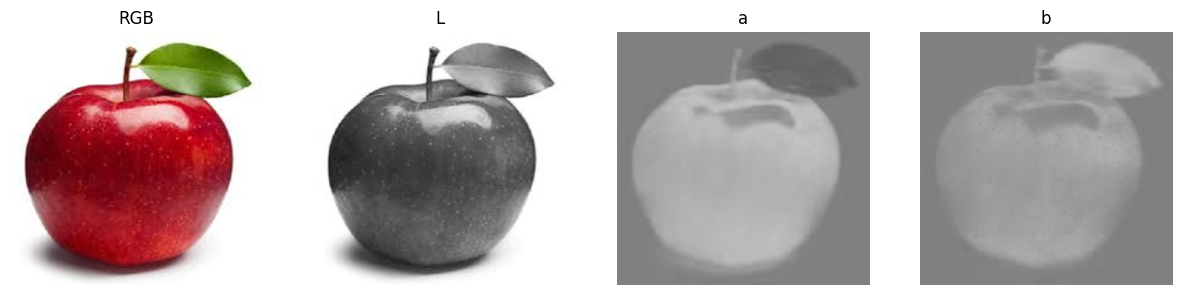

In [41]:
def showLAB(filename):
    
    img = Image.open(filename).resize([WIDTH, HEIGHT]).convert('RGB')
    LAB = skimage.color.rgb2lab(np.array(img)).astype(np.float32)

    plt.figure(figsize=(15, 60))

    ax = plt.subplot(1,4,1)
    plt.title("RGB")
    plt.imshow(img)
    plt.axis('off')
    
    ax = plt.subplot(1,4,2)
    plt.title("L")
    plt.imshow(LAB[:,:,0], cmap='gray', vmin=0, vmax=100)
    plt.axis('off')
    
    ax = plt.subplot(1,4,3)
    plt.title("a")
    plt.imshow(LAB[:,:,1], cmap='gray', vmin=-128, vmax=127)
    plt.axis('off')

    ax = plt.subplot(1,4,4)
    plt.title("b")
    plt.imshow(LAB[:,:,2], cmap='gray', vmin=-128, vmax=127)
    plt.axis('off')


showLAB( f'data/NCD/Color/Apple/Apple3.jpg')    

In [77]:
from datasets import load_dataset

train_ds = load_dataset(
    "nickpai/coco2017-colorization",
    split="train",
    revision="caption-free",
)
val_ds = load_dataset(
    "nickpai/coco2017-colorization",
    split="validation",
    revision="caption-free",
)

ModuleNotFoundError: No module named 'datasets'

# Create the Dataset

To construct the dataset, all RGB images are first converted to the CIELAB color space. The \(L^*\) channel is used as the model input, while the \(a^*\) and \(b^*\) channels are used as prediction targets. 

This formulation is common in image colorization because it separates lightness from chromatic information. As a result, the model only needs to predict plausible colors, instead of jointly reconstructing both brightness and color in RGB space. 

Using Lab in this way also makes the learning problem more structured: the input already contains most of the scene geometry, texture, and shading through the \(L^*\) channel, while the network focuses on estimating chromatic components in the \(a^*b^*\) plane. 

A practical limitation, however, is that the \(L^*\) channel obtained from a color image is not exactly the same as a conventional grayscale image generated by a standard RGB-to-grayscale conversion. Therefore, training on \(L^*\) extracted from color images does not perfectly match the real setting of colorizing arbitrary grayscale images. 

Some pipelines try to reduce this mismatch by first converting a grayscale image into a 3-channel RGB image, then transforming it to Lab and taking the resulting \(L^*\) channel. Even so, this does not guarantee that the obtained \(L^*\) values will coincide with those extracted from the original color image, so a small distribution shift may remain. 

To create the dataset a subclass of Dataset will be implemented. Since the dataset is fairly small the entire dataset will be loaded into memory as this will speed up training.

In addition to storing the $L$ and color channels, the dataset will also retain the class name and the original color image. These are included for visualization purposes only. 

In [42]:
class CustomDataLoader(torch.utils.data.Dataset):

    def __init__(self, path, transform = None):
        super().__init__()
        
        self.path = path

        self.transform = transform
        self.classes = [x.name for x in os.scandir(path) if x.is_dir()]
        self.classes_to_idx = {cls_name:i for i, cls_name in enumerate(self.classes)}
        self.paths = list(pathlib.Path(path,).glob('*/*.jpg'))
        self.data = []
        self.labels = []
        for p in self.paths:
           
                img = Image.open(p).resize([WIDTH, HEIGHT]).convert('RGB')
                class_name  = p.parent.name
                lab = skimage.color.rgb2lab(np.array(img)).astype(np.float32)

                l = (lab[:, :, 0:1]/50.0) - 1   # (H, W, 1)
                ab = lab[:, :, 1:]/127.0   # (H, W, 2)

                self.data.append([l, ab, class_name, np.array(img)])

    def __len__(self):
        return len(self.paths)    

    def __getitem__(self, idx):
        dat = self.data[idx]
        return self.transform(dat[0]), self.transform(dat[1]), dat[2] , dat[3]


**Dataset partitioning**

As there is no standard partition for this dataset, we opted for a random split with:

- 70% for training
- 20% for validation
- 10% for testing


In [43]:
transform = transforms.Compose(
    [transforms.ToTensor()]) 

dataset = CustomDataLoader('data/NCD/Color', transform)

train_size = int(0.7 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size 

generator = torch.Generator().manual_seed(42)
train_set, val_set, test_set = torch.utils.data.random_split(
    dataset, [train_size, val_size, test_size], generator=generator
)

train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size = BATCH_SIZE)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = BATCH_SIZE, shuffle=True)

Displaying some samples of the dataset

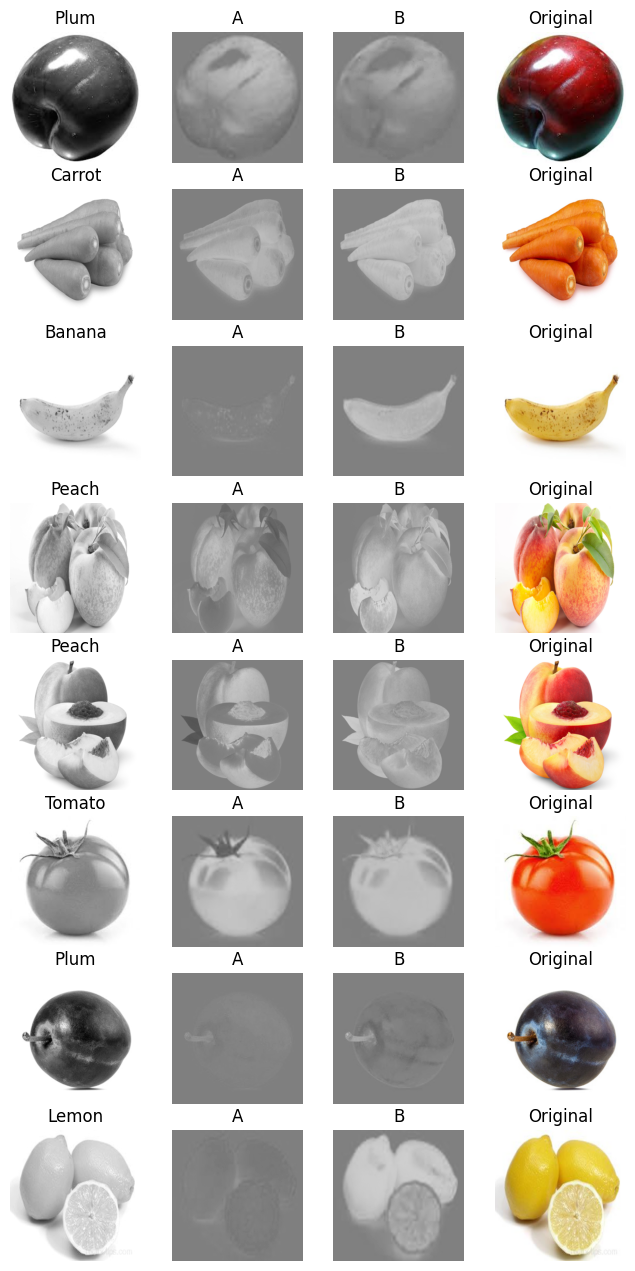

In [44]:
gray, AB, classes, original = next(iter(train_loader))

show_images(gray,AB, original, classes, 8)


# Architecture

Note on the model architecture. Although this model is described as an autoencoder for colorization, it does not learn a compact latent representation that is later decoded to reconstruct the input in the classical autoencoder sense. Instead, it receives the $L$ channel and directly predicts the missing $a$ and $b$ channels, so the task is better understood as conditional image-to-image prediction rather than reconstruction. Because multiple valid colorizations may correspond to the same luminance input, the network is not recovering a unique original image but estimating a plausible chrominance output from contextual cues.

In [60]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class ColorizationAE(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder: 256 -> 128 -> 64 -> 32 -> 16 -> 8
        self.enc1 = ConvBlock(1,   64, stride=2)
        self.enc2 = ConvBlock(64, 128, stride=2)
        self.enc3 = ConvBlock(128, 256, stride=2)
        self.enc4 = ConvBlock(256, 512, stride=2)
        self.enc5 = ConvBlock(512, 512, stride=2)

        # Bottleneck: fully convolutional, preserves spatial structure
        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

        # Decoder: 8 -> 16 -> 32 -> 64 -> 128 -> 256
        self.dec5 = UpBlock(512, 512)
        self.dec4 = UpBlock(512, 256)
        self.dec3 = UpBlock(256, 128)
        self.dec2 = UpBlock(128,  64)
        self.dec1 = UpBlock(64,   32)

        # Output ab channels
        self.out = nn.Sequential(
            nn.Conv2d(32, 2, kernel_size=1),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.enc1(x)   # 64 x 128 x 128
        x = self.enc2(x)   # 128 x 64 x 64
        x = self.enc3(x)   # 256 x 32 x 32
        x = self.enc4(x)   # 512 x 16 x 16
        x = self.enc5(x)   # 512 x 8 x 8

        x = self.bottleneck(x)

        x = self.dec5(x)   # 512 x 16 x 16
        x = self.dec4(x)   # 256 x 32 x 32
        x = self.dec3(x)   # 128 x 64 x 64
        x = self.dec2(x)   # 64 x 128 x 128
        x = self.dec1(x)   # 32 x 256 x 256

        x = self.out(x)    # 2 x 256 x 256
        return x

In [46]:
AE = ColorizationAE()
AE.to(device)
torchinfo.summary(AE, input_size=(BATCH_SIZE, 1, WIDTH, HEIGHT))

Layer (type:depth-idx)                   Output Shape              Param #
ColorizationAE                           [32, 2, 256, 256]         --
├─ConvBlock: 1-1                         [32, 64, 128, 128]        --
│    └─Sequential: 2-1                   [32, 64, 128, 128]        --
│    │    └─Conv2d: 3-1                  [32, 64, 128, 128]        576
│    │    └─BatchNorm2d: 3-2             [32, 64, 128, 128]        128
│    │    └─ReLU: 3-3                    [32, 64, 128, 128]        --
│    │    └─Conv2d: 3-4                  [32, 64, 128, 128]        36,864
│    │    └─BatchNorm2d: 3-5             [32, 64, 128, 128]        128
│    │    └─ReLU: 3-6                    [32, 64, 128, 128]        --
├─ConvBlock: 1-2                         [32, 128, 64, 64]         --
│    └─Sequential: 2-2                   [32, 128, 64, 64]         --
│    │    └─Conv2d: 3-7                  [32, 128, 64, 64]         73,728
│    │    └─BatchNorm2d: 3-8             [32, 128, 64, 64]         256
│  

# Training

In [47]:
if TRAIN:
    opt = torch.optim.Adam(AE.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', 
                                                               factor = 0.1, patience=3)
    loss_fn = torch.nn.MSELoss()
    early_stop = Early_Stopping(9)
        
    history=train(AE, train_loader, val_loader, 100, loss_fn, opt,  scheduler, early_stop, 
                      f'{MODEL_PATH}/color_ae' )

Epoch 1/100: 16it [00:01,  9.74it/s]


Epoch: 000 | Loss: 0.044835 | Val Loss: 0.032224 | Time: 1.8588s


Epoch 2/100: 16it [00:01, 11.35it/s]


Epoch: 001 | Loss: 0.031810 | Val Loss: 0.077900 | Time: 1.5684s


Epoch 3/100: 16it [00:01, 11.41it/s]


...

==> Learning rate updated: 0.000000 -> 0.000000
Epoch: 061 | Loss: 0.014798 | Val Loss: 0.016175 | Time: 1.6388s


Epoch 63/100: 16it [00:01, 10.77it/s]


Epoch: 062 | Loss: 0.014608 | Val Loss: 0.016129 | Time: 1.6557s


Epoch 64/100: 16it [00:01, 10.81it/s]


Epoch: 063 | Loss: 0.014769 | Val Loss: 0.016124 | Time: 1.6504s
Early stopping triggered!
Finished Training


In [52]:
reload = torch.load(f'{MODEL_PATH}/color_ae_best.pt')
print(reload['epoch'])
model = ColorizationAE()
model.to(device)
model.load_state_dict(reload['model'])

53


<All keys matched successfully>

# Evaluation

Since the goal of image colorization is to generate plausible colors rather than recover a uniquely correct original image, evaluation differs from standard image restoration tasks . In this setting, the model receives the \(L\) channel as input and predicts the \(a\) and \(b\) chrominance channels, so the task should be interpreted as conditional color prediction rather than strict reconstruction from a latent representation.

This distinction is important because there is no single correct colorization for a given grayscale image, even when the ground-truth color image is available. As a result, traditional pixel-wise measures such as MSE or PSNR can be useful as reference signals, but they are often insufficient and may be misleading when used alone to judge perceptual quality or realism.

A more appropriate assessment combines quantitative measures with qualitative inspection of the generated results. In particular, visual evaluation is essential to determine whether the predicted colors are coherent, natural, and semantically plausible for the scene or object being represented

C:\Users\anton\AppData\Local\Temp\ipykernel_40200\265977051.py:160: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 1 negative Z values that have been clipped to zero
  rgb = skimage.color.lab2rgb(lab)
C:\Users\anton\AppData\Local\Temp\ipykernel_40200\265977051.py:160: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 4 negative Z values that have been clipped to zero
  rgb = skimage.color.lab2rgb(lab)


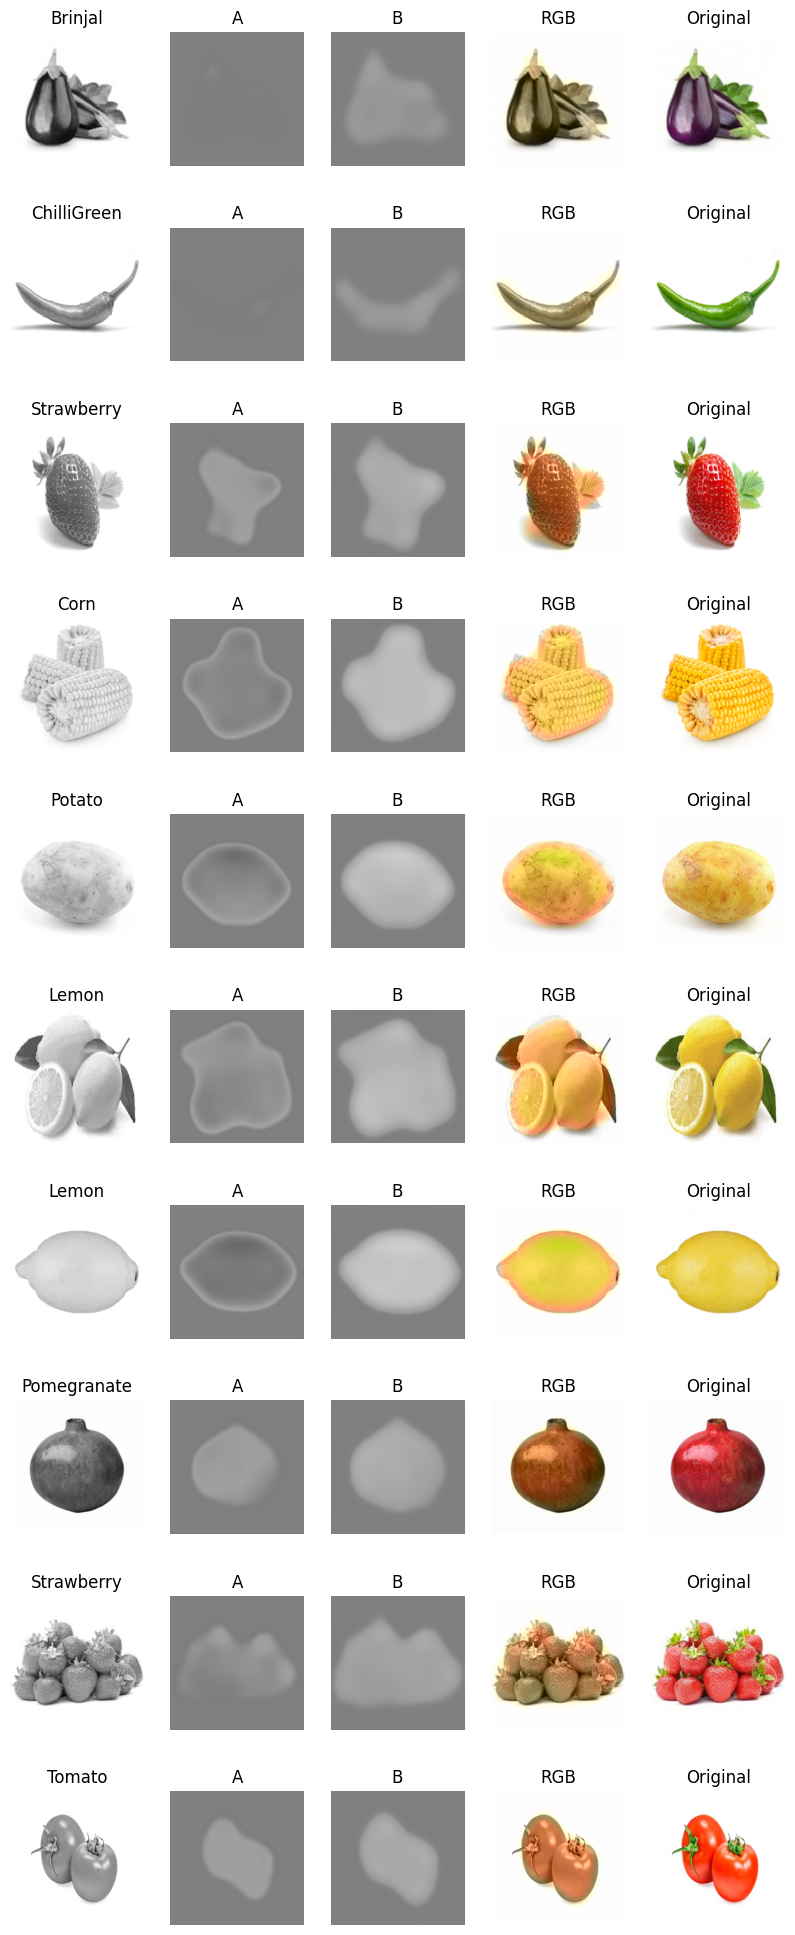

In [56]:
i, t, c, o = next(iter(test_loader))
recon = AE(i.to(device)).cpu().detach()
    
show_preds(i, recon, o, c, 10)

# U-Net for Colorization

The autoencoder presented previously follows a purely sequential encoder-decoder architecture, where the input image is compressed into a low-dimensional latent representation before being expanded back into the target output. Although effective, this compression can limit the model’s ability to preserve fine-grained spatial information that is often relevant for accurate image colorization.

To address this limitation, we now consider the U-Net architecture, a modified encoder-decoder network that introduces skip connections between encoder and decoder stages of equal spatial resolution. These skip connections help propagate low-level structural details directly to the decoder, improving the reconstruction of contours, regions, and texture transitions.

For the colorization task, this is particularly advantageous because the model must infer chromatic information while remaining aligned with the original luminance structure. Thus, U-Net offers a more suitable architectural bias for predicting the \(a\) and \(b\) channels from the \(L\) channel than a plain bottlenecked autoencoder.

The architecture has been originally proposed by  Olaf Ronneberger, Philipp Fischer and Thomas Brox in ["U-Net: Convolutional Networks for Biomedical Image Segmentation"](https://paperswithcode.com/paper/u-net-convolutional-networks-for-biomedical) (2015).


In [61]:
class UNet(nn.Module):
    def __init__(self, base_ch: int = 64):
        super().__init__()
        C = base_ch

        # Encoder
        # Input (B,1,256,256)
        self.enc1 = ConvBlock(1,   C,     stride=1)  # 256x256, C
        self.enc2 = ConvBlock(C,   C * 2, stride=2)  # 128x128, 2C
        self.enc3 = ConvBlock(C*2, C * 4, stride=2)  # 64x64, 4C
        self.enc4 = ConvBlock(C*4, C * 8, stride=2)  # 32x32, 8C
        self.enc5 = ConvBlock(C*8, C * 8, stride=2)  # 16x16, 8C (bottleneck)

        # Decoder (transpose convs upsample by factor 2 each time)
        self.up4 = UpBlock(C * 8, C * 8)  # 16 -> 32
        self.up3 = UpBlock(C * 16, C * 4) # 32 -> 64   (concat with enc4: 8C + 8C = 16C)
        self.up2 = UpBlock(C * 8,  C * 2) # 64 -> 128  (concat with enc3: 4C + 4C = 8C)
        self.up1 = UpBlock(C * 4,  C)     # 128 -> 256 (concat with enc2: 2C + 2C = 4C)

        # Final conv after last skip (enc1)
        self.out_conv = nn.Conv2d(C * 2, 2, kernel_size=3, padding=1)  # (B,2,256,256)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)  # (B,C,256,256)
        e2 = self.enc2(e1) # (B,2C,128,128)
        e3 = self.enc3(e2) # (B,4C,64,64)
        e4 = self.enc4(e3) # (B,8C,32,32)
        e5 = self.enc5(e4) # (B,8C,16,16)

        # Decoder with skips
        d4 = self.up4(e5)               # (B,8C,32,32)
        d4 = torch.cat([d4, e4], dim=1) # (B,16C,32,32)

        d3 = self.up3(d4)               # (B,4C,64,64)
        d3 = torch.cat([d3, e3], dim=1) # (B,8C,64,64)

        d2 = self.up2(d3)               # (B,2C,128,128)
        d2 = torch.cat([d2, e2], dim=1) # (B,4C,128,128)

        d1 = self.up1(d2)               # (B,C,256,256)
        d1 = torch.cat([d1, e1], dim=1) # (B,2C,256,256)

        out = self.out_conv(d1)         # (B,2,256,256)
        return out

In [62]:
UN = UNet()
UN.to(device)
torchinfo.summary(UN, input_size=(BATCH_SIZE, 1, WIDTH, HEIGHT))

Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [32, 2, 256, 256]         --
├─ConvBlock: 1-1                         [32, 64, 256, 256]        --
│    └─Sequential: 2-1                   [32, 64, 256, 256]        --
│    │    └─Conv2d: 3-1                  [32, 64, 256, 256]        576
│    │    └─BatchNorm2d: 3-2             [32, 64, 256, 256]        128
│    │    └─ReLU: 3-3                    [32, 64, 256, 256]        --
│    │    └─Conv2d: 3-4                  [32, 64, 256, 256]        36,864
│    │    └─BatchNorm2d: 3-5             [32, 64, 256, 256]        128
│    │    └─ReLU: 3-6                    [32, 64, 256, 256]        --
├─ConvBlock: 1-2                         [32, 128, 128, 128]       --
│    └─Sequential: 2-2                   [32, 128, 128, 128]       --
│    │    └─Conv2d: 3-7                  [32, 128, 128, 128]       73,728
│    │    └─BatchNorm2d: 3-8             [32, 128, 128, 128]       256
│  

In [63]:
if TRAIN:
    opt = torch.optim.Adam(UN.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', 
                                                               factor = 0.1, patience=3)
    loss_fn = torch.nn.MSELoss()
    early_stop = Early_Stopping(9)
        
    history=train(UN, train_loader, val_loader, 100, loss_fn, opt,  scheduler, early_stop, 
                      f'{MODEL_PATH}/color_unet' )

Epoch 1/100: 16it [00:12,  1.24it/s]


Epoch: 000 | Loss: 0.077594 | Val Loss: 0.054269 | Time: 13.8142s


Epoch 2/100: 16it [00:06,  2.32it/s]


Epoch: 001 | Loss: 0.020101 | Val Loss: 0.020141 | Time: 7.7152s


Epoch 3/100: 16it [00:06,  2.35it/s]


...

==> Learning rate updated: 0.000001 -> 0.000000
Epoch: 036 | Loss: 0.013552 | Val Loss: 0.014352 | Time: 7.2881s


Epoch 38/100: 16it [00:06,  2.30it/s]


Epoch: 037 | Loss: 0.013283 | Val Loss: 0.014347 | Time: 7.6300s


Epoch 39/100: 16it [00:07,  2.13it/s]


Epoch: 038 | Loss: 0.013958 | Val Loss: 0.014403 | Time: 8.3587s
Early stopping triggered!
Finished Training


In [64]:
reload = torch.load(f'{MODEL_PATH}/color_unet_best.pt')
print(reload['epoch'])
model = UNet()
model.to(device)
model.load_state_dict(reload['model'])

28


<All keys matched successfully>

C:\Users\anton\AppData\Local\Temp\ipykernel_40200\265977051.py:160: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 36 negative Z values that have been clipped to zero
  rgb = skimage.color.lab2rgb(lab)


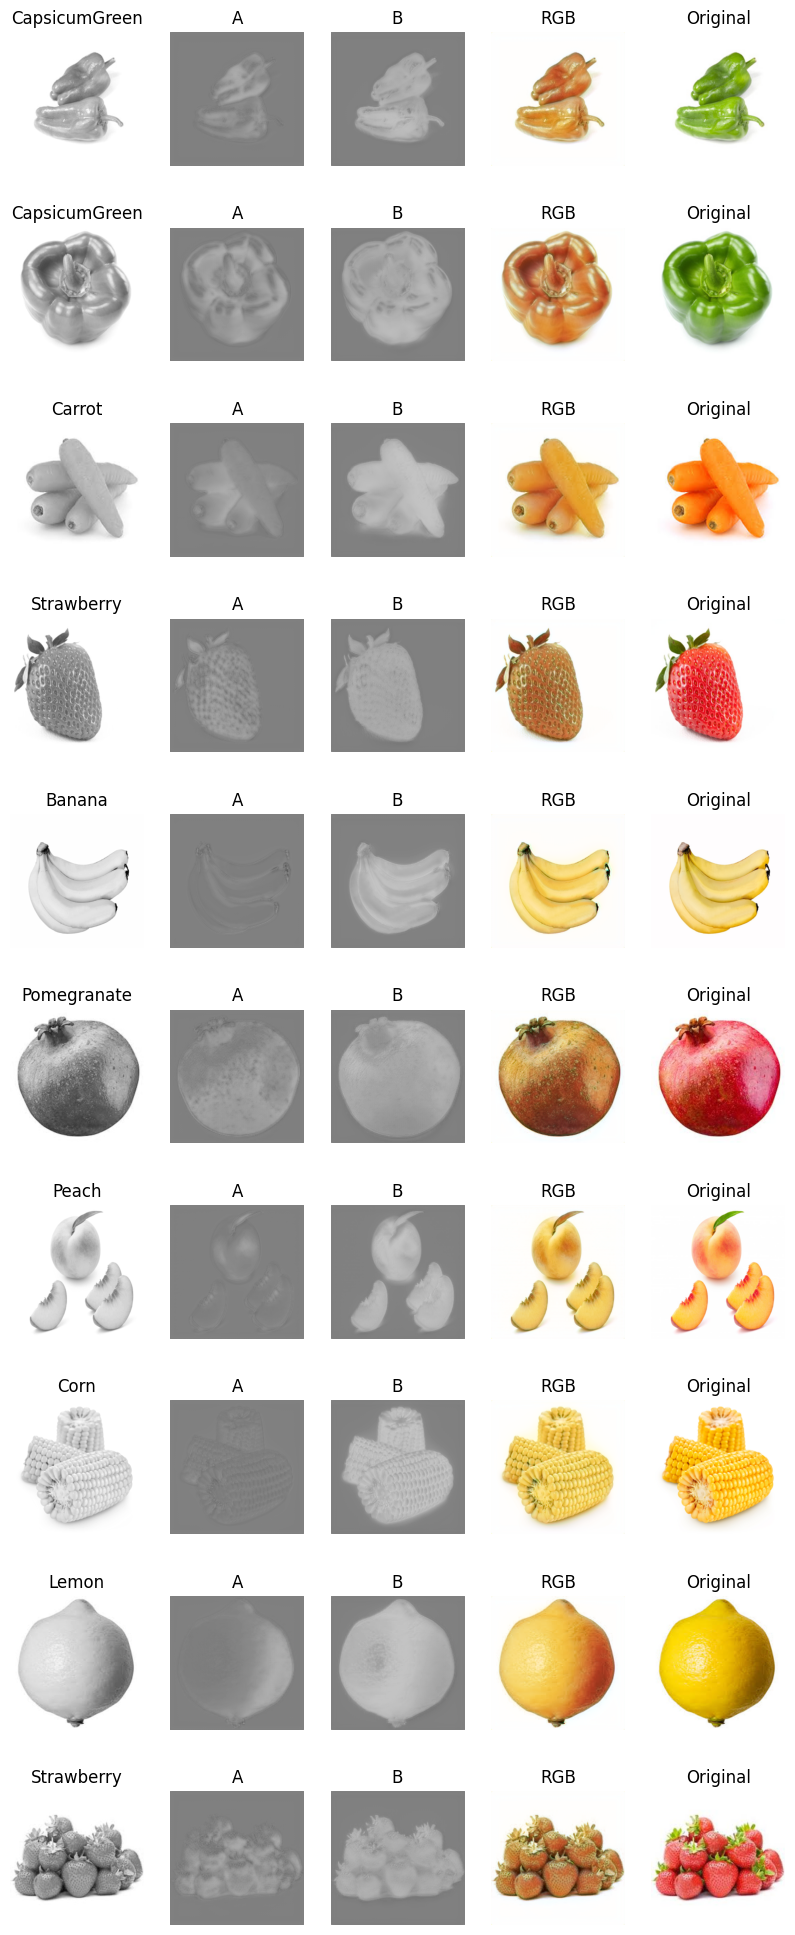

In [65]:
i, t, c, o = next(iter(test_loader))
recon = UN(i.to(device)).cpu().detach()
    
show_preds(i, recon, o, c, 10)

In [71]:
inputs, targets, *_ = next(iter(val_loader))
print("targets.shape:", targets.shape)

targets.shape: torch.Size([32, 2, 256, 256])


In [75]:
ae_stats = collect_color_stats(AE, val_loader, device, max_batches=10)
um_stats = collect_color_stats(UN, val_loader, device, max_batches=10)

print("Autoencoder stats:")
print(ae_stats)

print("\nUNet stats:")
print(um_stats)

Autoencoder stats:
{'pred_a': {'mean': 0.047420281916856766, 'std': 0.08541703969240189, 'min': -0.22403281927108765, 'max': 0.29444414377212524}, 'pred_b': {'mean': 0.12715336680412292, 'std': 0.15806762874126434, 'min': -0.01069815456867218, 'max': 0.6392786502838135}, 'gt_a': {'mean': 0.034553948789834976, 'std': 0.16359764337539673, 'min': -0.49805083870887756, 'max': 0.6405774354934692}, 'gt_b': {'mean': 0.1282525360584259, 'std': 0.1887279897928238, 'min': -0.351800799369812, 'max': 0.7208664417266846}, 'hist_pred_a': [0, 0, 12766, 1843397, 5469776, 2022551, 88694, 0], 'hist_pred_b': [0, 0, 0, 1331697, 4240417, 1224300, 2524734, 116036], 'hist_gt_a': [0, 277004, 805403, 5621242, 1111489, 525394, 906059, 190593], 'hist_gt_b': [0, 319, 56515, 619487, 5359323, 887418, 1937725, 576397], 'hist_bins': [-1.0, -0.5, -0.25, -0.1, 0.0, 0.1, 0.25, 0.5, 1.0]}

UNet stats:
{'pred_a': {'mean': 0.045652229338884354, 'std': 0.09250295907258987, 'min': -0.4465728998184204, 'max': 0.53616613149642